---
title: "Marginal transforms: ECDF & histograms"
short_title: "00 · ECDF & histograms"
subtitle: "The atom of Gaussianization — rank → uniform → normal — and where the empirical CDF breaks"
description: >
  The 1D probability integral transform z = Phi^{-1}(F(x)) is the building
  block every Gaussianization method stacks. We estimate F with the empirical
  CDF and a histogram CDF, watch Glivenko-Cantelli convergence, run the
  rank -> uniform -> normal pipeline with rbig and gauss_flows, and see the
  tail/boundary failure that motivates the smoother estimators of Part 1.
---

(sec-nb-mt-00)=
# 00 — Marginal transforms: ECDF & histograms

Part 0 showed *what* a density destructor is. Part 1 builds its **atom**: the
per-coordinate map that turns one messy marginal into a standard normal. Every
method in this curriculum — RBIG, coupling flows, spline flows — is ultimately
a stack of these 1D transforms interleaved with rotations. Get the 1D piece
right and the rest is composition ([notebook 01 of Part 0](../00_foundations/01_composition_logdet.ipynb)).

**What you will see**

- The **probability integral transform** $z = \Phi^{-1}(F(x))$ and why it
  Gaussianizes *any* continuous marginal — if we know $F$.
- Estimating $F$ with the **empirical CDF** and a **histogram CDF**.
- **Glivenko–Cantelli**: the ECDF converges uniformly to $F$ as $n\to\infty$.
- The **rank → uniform → normal** pipeline with `rbig` and `gauss_flows`.
- The **boundary failure** of the ECDF in the tails — the motivation for the
  smooth estimators (KDE, mixtures, splines) in the rest of Part 1.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

import gauss_flows as gf
import rbig
from _style import GAUSS_KW, style_ax

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(10)

# A skewed, strictly-positive marginal to Gaussianize (well away from normal).
x = rng.exponential(1.0, size=(6000, 1))

## 1. The probability integral transform

The whole idea rests on one classical fact. If a continuous random variable
$X$ has strictly increasing CDF $F$, then **$F(X)$ is uniform on $[0, 1]$**
(the *probability integral transform*, PIT). Composing with the standard-normal
quantile $\Phi^{-1}$ then sends that uniform to a standard normal:

$$
U = F(X) \sim \mathrm{Uniform}[0,1],
\qquad
Z = \Phi^{-1}(U) = \Phi^{-1}\big(F(X)\big) \sim \mathcal{N}(0, 1).
$$

So in 1D we can Gaussianize *exactly* — **given** the true $F$. The catch is
that we never know $F$; we must estimate it from samples. The two simplest
estimators are the empirical CDF and the histogram, and seeing how (and where)
they fail sets up everything else in Part 1.

## 2. The empirical CDF and Glivenko–Cantelli

The **empirical CDF** just counts:

$$
\hat F_n(t) = \frac{1}{n}\sum_{i=1}^{n}\mathbf{1}\{x_i \le t\}.
$$

It is a right-continuous staircase that jumps by $1/n$ at each sample. The
**Glivenko–Cantelli theorem** guarantees it converges *uniformly* to the truth,
$\sup_t |\hat F_n(t) - F(t)| \to 0$ almost surely, and the
Dvoretzky–Kiefer–Wolfowitz bound {cite}`dvoretzky1956dkw` says the sup-gap
shrinks like $n^{-1/2}$. So
with enough data the ECDF *is* a good $F$ — let's watch it converge.

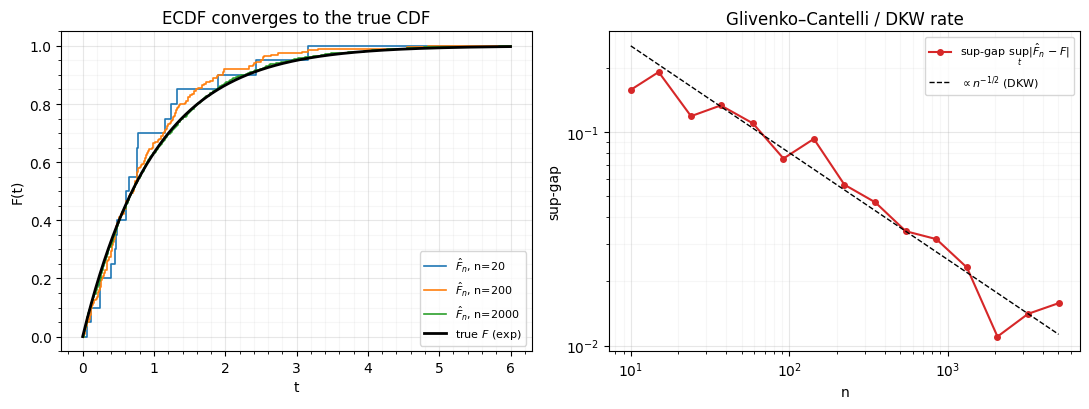

In [2]:
def ecdf(samples, t):
    return np.searchsorted(np.sort(samples), t, side="right") / len(samples)


grid = np.linspace(0, 6, 400)
true_cdf = stats.expon.cdf(grid)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for n in [20, 200, 2000]:
    axes[0].step(grid, ecdf(x[:n, 0], grid), where="post", lw=1.2, label=f"$\\hat F_n$, n={n}")
axes[0].plot(grid, true_cdf, "k-", lw=2, label="true $F$ (exp)")
axes[0].set(title="ECDF converges to the true CDF", xlabel="t", ylabel="F(t)")
axes[0].legend(fontsize=8); style_ax(axes[0])

ns = np.logspace(1, 3.7, 15).astype(int)
sup_err = [np.max(np.abs(ecdf(x[:n, 0], grid) - stats.expon.cdf(grid))) for n in ns]
axes[1].loglog(ns, sup_err, "-o", color="tab:red", ms=4, label="sup-gap $\\sup_t|\\hat F_n - F|$")
axes[1].loglog(ns, 0.8 / np.sqrt(ns), "k--", lw=1, label=r"$\propto n^{-1/2}$ (DKW)")
axes[1].set(title="Glivenko–Cantelli / DKW rate", xlabel="n", ylabel="sup-gap")
axes[1].legend(fontsize=8); style_ax(axes[1])
fig.tight_layout()

Left: the staircase $\hat F_n$ tightens onto the smooth true CDF as $n$ grows.
Right: the worst-case gap falls along the $n^{-1/2}$ DKW line. So the ECDF is a
*consistent* estimate of $F$ — the foundation under "rank-based" Gaussianization.

## 3. Rank → uniform → normal

Plugging the ECDF into the PIT gives the **rank transform**: a sample's
uniform value is essentially its rank over $n$, and $\Phi^{-1}$ of that is its
Gaussianized value. `rbig.MarginalUniformize` does the rank→uniform step and
`rbig.MarginalGaussianize` the whole rank→uniform→normal map; `gauss_flows`
splits it into a `HistogramCDF` (→ uniform) composed with `InverseGaussCDF`
(→ normal). We run the pipeline and check each stage.

rbig vs gauss_flows uniform stage agree: max|Δ| = 0.035


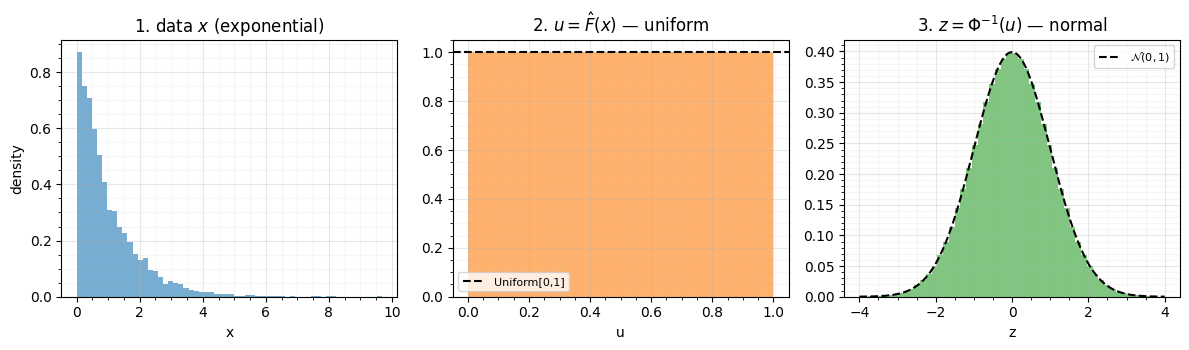

In [3]:
u_rbig = rbig.MarginalUniformize().fit(x).transform(x)          # rank -> uniform
z_rbig = rbig.MarginalGaussianize().fit(x).transform(x)         # -> normal

hist = gf.HistogramCDF(n_bins=64, shape=(1,), method="linear").fit(jnp.asarray(x))
u_gf = np.asarray(jax.vmap(hist.transform)(jnp.asarray(x)))     # histogram -> uniform
z_gf = stats.norm.ppf(np.clip(u_gf, 1e-6, 1 - 1e-6))           # -> normal

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
axes[0].hist(x[:, 0], bins=60, density=True, color="tab:blue", alpha=0.6)
axes[0].set(title="1. data $x$ (exponential)", xlabel="x", ylabel="density")
axes[1].hist(u_rbig[:, 0], bins=40, density=True, color="tab:orange", alpha=0.6)
axes[1].axhline(1.0, **GAUSS_KW, label="Uniform[0,1]")
axes[1].set(title=r"2. $u = \hat F(x)$ — uniform", xlabel="u"); axes[1].legend(fontsize=8)
zz = np.linspace(-4, 4, 200)
axes[2].hist(z_rbig[:, 0], bins=50, density=True, color="tab:green", alpha=0.6)
axes[2].plot(zz, stats.norm.pdf(zz), **GAUSS_KW, label=r"$\mathcal{N}(0,1)$")
axes[2].set(title=r"3. $z = \Phi^{-1}(u)$ — normal", xlabel="z"); axes[2].legend(fontsize=8)
for a in axes:
    style_ax(a)
fig.tight_layout()

print(f"rbig vs gauss_flows uniform stage agree: "
      f"max|Δ| = {np.max(np.abs(np.sort(u_rbig[:,0]) - np.sort(u_gf[:,0]))):.3f}")

The exponential is pulled to a flat uniform and then to a clean bell — the PIT
working through two different $F$-estimators that agree closely. Note the price
the ECDF pays at the edges, which the next section makes explicit.

## 4. The boundary problem (and support extension)

The ECDF assigns the largest sample $\hat F \approx 1$ and the smallest
$\approx 0$, and it knows *nothing* beyond the observed range. Feed those
near-$\{0,1\}$ values to $\Phi^{-1}$ and the tail samples cannot be recovered on
the way back — the round-trip blows up (the failure of
[Part 0 notebook 05](../00_foundations/05_numerical_mechanics.ipynb)). `rbig`'s
remedy is **support extension** (`pdf_extension`): pad the estimated density a
fraction of the data range past the extremes, giving the inverse room to place
tail samples instead of pinning them at the boundary.

pdf_extension =  0.0:  round-trip max error = 7.616e-01
pdf_extension =  0.1:  round-trip max error = 1.170e-02


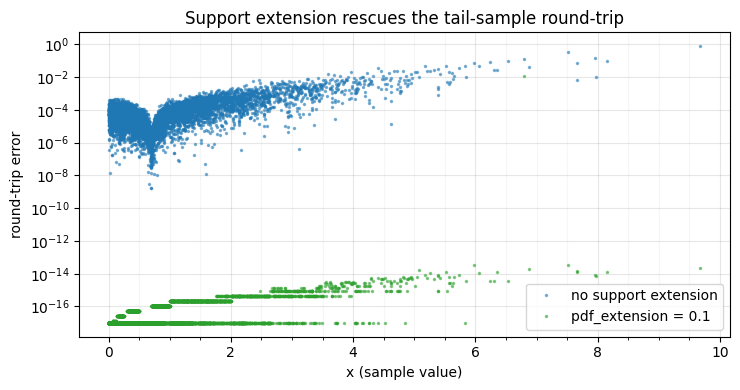

In [4]:
for pe in [0.0, 0.1]:
    mu = rbig.MarginalUniformize(pdf_extension=pe).fit(x)
    err = np.abs(x - mu.inverse_transform(mu.transform(x))).max()
    print(f"pdf_extension = {pe:>4}:  round-trip max error = {err:.3e}")

mu0 = rbig.MarginalUniformize(pdf_extension=0.0).fit(x)
mu1 = rbig.MarginalUniformize(pdf_extension=0.1).fit(x)
err0 = np.abs(x - mu0.inverse_transform(mu0.transform(x))).ravel()
err1 = np.abs(x - mu1.inverse_transform(mu1.transform(x))).ravel()

fig, ax = plt.subplots(figsize=(7.5, 4))
order = np.argsort(x.ravel())
ax.semilogy(x.ravel()[order], np.maximum(err0[order], 1e-17), ".", ms=3,
            alpha=0.5, label="no support extension")
ax.semilogy(x.ravel()[order], np.maximum(err1[order], 1e-17), ".", ms=3,
            alpha=0.5, color="tab:green", label="pdf_extension = 0.1")
ax.set(title="Support extension rescues the tail-sample round-trip",
       xlabel="x (sample value)", ylabel="round-trip error")
ax.legend(); style_ax(ax)
fig.tight_layout()

Support extension drops the worst-case round-trip error by ~60× (the spike is
all at the largest samples). But it is a *heuristic* — a guess about mass past
the data — and a rank/ECDF map is still *piecewise constant between samples*
with no real tail model. That is the core limitation of empirical estimators,
and the reason Part 1 now turns to **smooth** parametric CDFs.

## 5. The Jacobian: the gradient that becomes the log-det

A marginal earns its place in a *flow* only if we can compute its
**log-determinant** — the per-coordinate gradient $T'(x) = \mathrm{d}z/\mathrm{d}x$
that change of variables (Part 0
[00](../00_foundations/00_change_of_variables.ipynb)) turns into $\log p(x)$.
For $z = \Phi^{-1}(F(x))$ the chain rule gives

$$
\frac{\mathrm{d}z}{\mathrm{d}x} = \frac{F'(x)}{\varphi(z)} = \frac{f(x)}{\varphi(z)},
\qquad
\log\big|T'(x)\big| = \log f(x) - \log\varphi(z),
$$

where $f = F'$ is the estimated **density** and $\varphi$ the standard-normal
pdf — so a marginal's log-det is *its own density, in log space, re-referenced
to the Gaussian*. This exposes a second flaw in the pure ECDF: $\hat F_n$ is a
staircase, so its "density" is a sum of point masses — $f = 0$ between samples
and $\log|T'| = -\infty$. **The rank/ECDF transform Gaussianizes but has no
usable Jacobian, so it is not a density model.** The histogram CDF gives the
first finite (if piecewise-constant) log-det.

histogram Jacobian: finite but piecewise-constant; the bare ECDF would be 0 between samples -> log-det = -inf


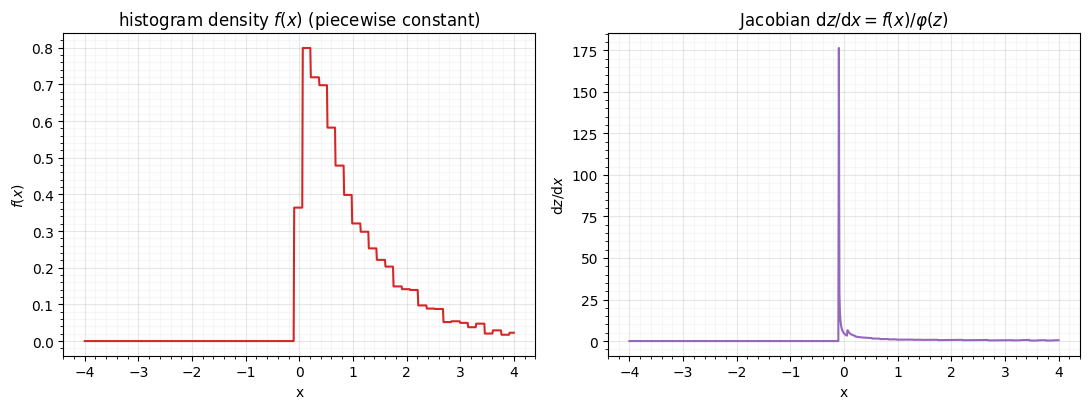

In [5]:
xg = np.linspace(-4, 4, 800)[:, None]
u_h, log_f = jax.vmap(hist.transform_and_log_det)(jnp.asarray(xg))
u_h, log_f = np.asarray(u_h).ravel(), np.asarray(log_f).ravel()  # u=F(x), log_f=log f(x)
z_h = stats.norm.ppf(np.clip(u_h, 1e-6, 1 - 1e-6))
dzdx = np.exp(log_f) / stats.norm.pdf(z_h)                       # f(x) / phi(z)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(xg.ravel(), np.exp(log_f), color="tab:red", lw=1.5)
axes[0].set(title=r"histogram density $f(x)$ (piecewise constant)",
            xlabel="x", ylabel="$f(x)$")
style_ax(axes[0])
axes[1].plot(xg.ravel(), dzdx, color="tab:purple", lw=1.5)
axes[1].set(title=r"Jacobian $\mathrm{d}z/\mathrm{d}x = f(x)/\varphi(z)$",
            xlabel="x", ylabel=r"$\mathrm{d}z/\mathrm{d}x$")
style_ax(axes[1])
fig.tight_layout()
print("histogram Jacobian: finite but piecewise-constant; "
      "the bare ECDF would be 0 between samples -> log-det = -inf")

The density (left) is the staircase's derivative — flat within each bin — and
the Jacobian $f(x)/\varphi(z)$ (right) inherits that bin structure, blowing up
in the tails where $\varphi(z)\to 0$. It is *finite* (unlike the ECDF's), but
jagged. A flow wants a **smooth** $f$ so the log-det is smooth and
differentiable — exactly what the KDE and mixture/spline CDFs of the next
notebooks provide.

## Recap

| step | object | tool |
|---|---|---|
| rank → uniform | empirical CDF $\hat F_n$ | `rbig.MarginalUniformize`, `gf.HistogramCDF` |
| uniform → normal | $\Phi^{-1}$ | `scipy`/`jax` `norm.ppf`, `gf.InverseGaussCDF` |
| full marginal map | $\Phi^{-1}\!\circ\hat F_n$ | `rbig.MarginalGaussianize` |
| consistency | Glivenko–Cantelli / DKW $n^{-1/2}$ | from scratch |
| tail fix | boundary correction, support extension | `bound_correct`, `pdf_extension` |

**Next up.** Empirical CDFs are consistent but jagged and tail-blind.
[01 — KDE & Gaussian-mixture CDFs](01_kde_mixture_cdf.ipynb) replaces the
staircase with a *smooth* density estimate, giving an analytic, differentiable,
tail-aware marginal transform.